# Text Annotations

An annotation turns a chart into an argument: it names what the reader should see, such as a record, a turning point, or its cause. Every chart function takes a `texts` parameter that writes notes onto the chart, with an optional connector to the data point a note is about, and the [datachart.utils.Annotate](../../../references/utils/#datachart.utils.Annotate) function adds notes to a figure that is already drawn. This guide shows both, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-annotations), which maps common tasks to the attribute or style key that does the job.

In [1]:
from datachart.charts import BarChart, LineChart
from datachart.utils import Annotate, Grid, Panel

## Basics

The examples in this guide share one dataset: the monthly climate normals of Ljubljana's weather station, rounded from the published 1991–2020 values. `TEMPERATURE` holds the mean temperature of each month (in °C) and `PRECIPITATION` its total precipitation (in mm), and `STATION_TEMPERATURES` adds the mean monthly temperature of two contrasting stations, coastal Portorož and Kredarica, high in the Julian Alps. The data lives in a hidden cell. The numbers have stories a chart alone does not tell: the warmest month, the wettest season, and a mountain that stays below freezing for half the year.

In [2]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# mean monthly temperature in °C
TEMPERATURE = [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3]
# total monthly precipitation in mm
PRECIPITATION = [69, 70, 88, 99, 109, 144, 115, 137, 147, 147, 130, 107]

# mean monthly temperature (°C) of three stations
STATION_TEMPERATURES = {
    "Ljubljana": TEMPERATURE,
    "Portorož (coast)": [5.2, 5.9, 9.3, 13.3, 17.8, 21.7, 23.9, 23.7, 19.2, 14.9, 10.4, 6.2],
    "Kredarica (2,514 m)": [-7.1, -7.7, -5.3, -2.0, 2.6, 6.4, 9.0, 9.0, 5.3, 1.8, -3.0, -6.3],
}

temperature_data = [{"x": i, "y": value} for i, value in enumerate(TEMPERATURE)]
precipitation_data = [
    {"label": month, "y": value} for month, value in zip(MONTHS, PRECIPITATION)
]

The temperature is a line chart with one data point per month, the month index as `x`:

In [3]:
temperature_data[:3]

[{'x': 0, 'y': 0.8}, {'x': 1, 'y': 2.4}, {'x': 2, 'y': 6.8}]

An annotation is a dictionary, and `texts` takes one of them or a list. Three keys are required: `text` is what the note says (a `\n` breaks the line), and `x` and `y` are where it sits, in the chart's data coordinates unless the note says otherwise. The optional `target` is the data point the note is about, as an `(x, y)` tuple: giving one draws a connector from the note to that point. Two more optional keys, `coords` and `style`, are covered in the sections below; the full definition is the [datachart.typings.TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs) type.

**Basic example.** A note that names the warmest month and points at it. The note sits at month 1 and 26 °C, in the empty space above the curve (the y-axis is extended to 30 °C to make room), and the connector runs to July (month 6, 22.0 °C):

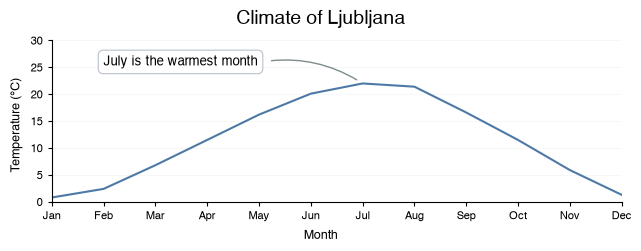

In [4]:
from datachart.constants import FIG_SIZE

LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    # one note, pointing at July
    texts={
        "text": "July is the warmest month",
        "x": 1,
        "y": 26,
        "target": (6, 22.0),
    },
).show()

The annotation is part of the chart declaration, not something drawn onto the finished image: it follows the active theme and is redrawn with the chart when the figure is composed with [Panel](../panel/) or [Grid](../grid/).

## Customizing the Annotations

Every customization is either a key of the annotation dictionary, a `plot_text_*` key of its `style` dictionary, or the way the annotation reaches the figure. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                        | Use                                                                   | See |
| :------------------------------------------------ | :-------------------------------------------------------------------- | :-- |
| write a note on a chart                           | `texts` with `text`, `x`, `y`                                         | [Basics](#basics) |
| place a note next to the data it describes        | `x`, `y` in data coordinates (the default)                            | [Placement and coordinates](#placement-and-coordinates) |
| pin a note to a corner, whatever the axis limits  | `"coords": "axes"`                                                    | [Placement and coordinates](#placement-and-coordinates) |
| point a note at a data point                      | `target`                                                              | [Targets and connectors](#targets-and-connectors) |
| change the connector look                         | `"style": {"plot_text_arrow_style": ...}`                             | [Connector looks](#connector-looks) |
| bend, recolor, or thicken the connector           | `plot_text_arrow_curve`, `plot_text_arrow_color`, `plot_text_arrow_width` | [Connector looks](#connector-looks) |
| restyle the text or its box                       | the `plot_text_*` keys in `style`                                     | [Text and box style](#text-and-box-style) |
| write a quiet, label-like note                    | `"style": {"plot_text_box_visible": False}`                           | [Text and box style](#text-and-box-style) |
| annotate each subplot of a chart                  | `texts` as a list of lists                                            | [Annotating subplots](#annotating-subplots) |
| annotate a figure that is already drawn           | `Annotate(figure, texts)`                                             | [Annotating Finished Figures](#annotating-finished-figures) |
| annotate a panel                                  | `Annotate` on the `Panel` figure                                      | [Annotating a panel](#annotating-a-panel) |
| annotate one subplot of a finished figure         | `Annotate` with the `subplot` index                                   | [Annotating finished subplots](#annotating-finished-subplots) |
| annotate a figure that goes into a grid           | `Annotate` before `Grid`                                              | [Annotations in a grid](#annotations-in-a-grid) |
| change the defaults of every annotation           | `config.update_config` with the `plot_text_*` keys                    | [Text Configuration](#text-configuration) |
| save the chart to a file                          | `save_figure`                                                         | [Saving Figures](../saving/) guide |

The parameter that accepts a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `style={"plot_text_arrow_style": ...}` | [`ARROW_STYLE`](../../../references/constants/#datachart.constants.ARROW_STYLE) |

The annotation keys are listed in the [datachart.typings.TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs) type and the style keys in [datachart.typings.TextStyleAttrs](../../../references/typings/#datachart.typings.TextStyleAttrs); the `Annotate` parameters are in the [datachart.utils.Annotate](../../../references/utils/#datachart.utils.Annotate) reference.

### Placement and coordinates

A note either belongs to a place in the data or to the chart as a whole, and the coordinates say which. By default `x` and `y` are data coordinates: the note sits among the data it describes and moves with it when the axis limits change. That is the right choice for a note about a month, a peak, or an event. With `"coords": "axes"` the position is a fraction of the axes instead, `(0, 0)` the bottom-left corner and `(1, 1)` the top-right, so the note stays in its place whatever the limits. That is the right choice for a note about the whole chart (the data source, the period, a caveat), and for a note that must not land on the data when the data changes. The example places one note of each kind; the y-axis is extended to 30 °C to leave room above the curve, and the axes note stays in the top-left corner regardless.

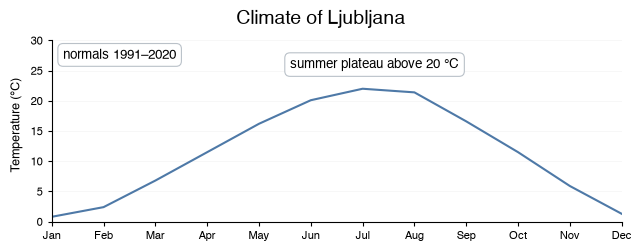

In [5]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    texts=[
        # about the whole chart: pinned to the top-left corner of the axes
        {"text": "normals 1991–2020", "x": 0.02, "y": 0.92, "coords": "axes"},
        # about the summer: placed in data coordinates, above July and August
        {"text": "summer plateau above 20 °C", "x": 4.6, "y": 26},
    ],
).show()

### Targets and connectors

A note next to a curve is only clear when it is obvious which point it means; a connector removes the doubt. `target` is the `(x, y)` data point the note is about, and it is **always** in data coordinates, even when the note itself is placed on the axes, so a note pinned to a corner still points at its data point. One annotation has one target; two points need two annotations. Place the note in open space some distance from its target, so the connector has room to be drawn. A connector with little room straightens out instead of curving, and one with no room left — a target the note's own box already covers — is left out.

The two coldest months of the year are January and December; each note below points at one of them, and both notes are placed as axes fractions in open space.

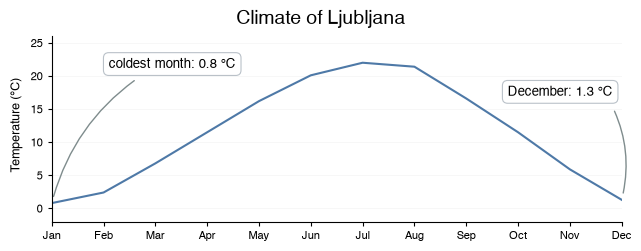

In [6]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymin=-2,
    ymax=26,
    texts=[
        # placed on the axes, pointing at a data point
        {
            "text": "coldest month: 0.8 °C",
            "x": 0.1,
            "y": 0.85,
            "coords": "axes",
            "target": (0, TEMPERATURE[0]),
        },
        # one target per annotation
        {
            "text": "December: 1.3 °C",
            "x": 0.8,
            "y": 0.7,
            "coords": "axes",
            "target": (11, TEMPERATURE[11]),
        },
    ],
).show()

### Connector looks

A connector can be a quiet hint or a pointer that demands attention, and the look says which. The look is set by the `plot_text_arrow_style` key of the annotation's `style`, one of the [ARROW_STYLE](../../../references/constants/#datachart.constants.ARROW_STYLE) constants. Each is a complete look (the line shape, its curvature, and the gap on the text side): `CURVE`, the default, is a plain curved line; `CURVE_ARROW` adds an arrowhead; `STRAIGHT` is a plain straight line; `TOUCHING` is a straight line that starts flush at the box border; and `ARROW` is a straight line with an arrowhead. A raw matplotlib arrow style string (such as `"-|>"`) is accepted too. The chart below shows the five looks side by side:

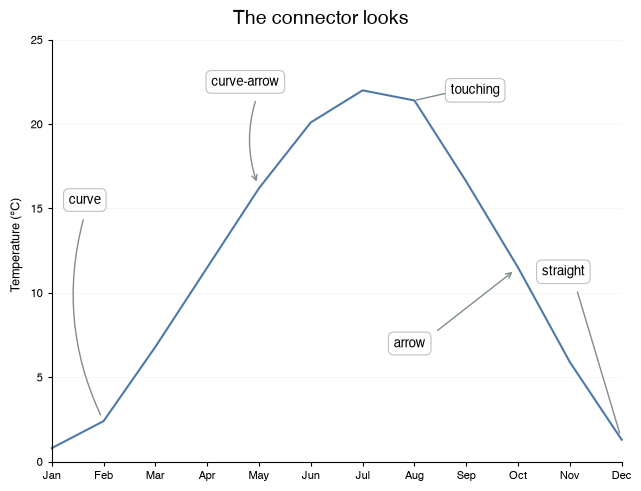

In [7]:
from datachart.constants import ARROW_STYLE

# (look, note position as axes fractions, target month)
looks = [
    (ARROW_STYLE.CURVE, 0.03, 0.62, 1),
    (ARROW_STYLE.CURVE_ARROW, 0.28, 0.9, 4),
    (ARROW_STYLE.TOUCHING, 0.7, 0.88, 7),
    (ARROW_STYLE.ARROW, 0.6, 0.28, 9),
    (ARROW_STYLE.STRAIGHT, 0.86, 0.45, 11),
]

LineChart(
    data=temperature_data,
    title="The connector looks",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    texts=[
        {
            "text": look,
            "x": x,
            "y": y,
            "coords": "axes",
            "target": (month, TEMPERATURE[month]),
            # the connector look of this note
            "style": {"plot_text_arrow_style": look},
        }
        for look, x, y, month in looks
    ],
).show()

A curved connector places itself: it leaves the box from the side facing the target and bows toward the side with the most open space, away from the chart's data. When that choice is not the one you want, the `plot_text_arrow_*` keys override single properties of the look. `plot_text_arrow_curve` pins the bow: a signed number, where positive and negative values bow to opposite sides, larger values bow deeper, and `0` draws a straight line. `plot_text_arrow_color` and `plot_text_arrow_width` restyle the stroke. The example keeps the arrowhead look and pins a deep bow, in the color of the note's message:

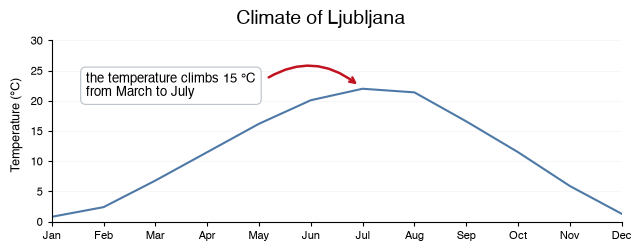

In [8]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    texts={
        "text": "the temperature climbs 15 °C\nfrom March to July",
        "x": 0.06,
        "y": 0.75,
        "coords": "axes",
        "target": (6, TEMPERATURE[6]),
        "style": {
            "plot_text_arrow_style": ARROW_STYLE.CURVE_ARROW,
            # a pinned bow, a red and thicker stroke
            "plot_text_arrow_curve": -0.4,
            "plot_text_arrow_color": "#c1121f",
            "plot_text_arrow_width": 1.8,
        },
    },
).show()

### Text and box style

A chart can carry notes of different weight: a main message that should stand out, and a quiet label that should not compete with the data. The `plot_text_*` keys of the annotation's `style` set the text (color, size, weight, alignment, alpha) and its background box (visibility, face and edge color, edge width, alpha); they are the same keys every theme sets, so a per-note override changes exactly one annotation. Hiding the box with `plot_text_box_visible` turns a note into a label that sits directly on the chart, the right look for naming a line or a region.

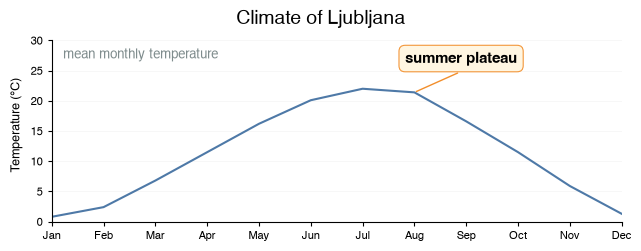

In [9]:
LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    texts=[
        # a quiet, boxless label
        {
            "text": "mean monthly temperature",
            "x": 0.02,
            "y": 0.92,
            "coords": "axes",
            "style": {"plot_text_box_visible": False, "plot_text_color": "#7F8C8D"},
        },
        # the main message: bold text, a colored box and connector
        {
            "text": "summer plateau",
            "x": 0.62,
            "y": 0.9,
            "coords": "axes",
            "target": (7, TEMPERATURE[7]),
            "style": {
                "plot_text_weight": "bold",
                "plot_text_size": 11,
                "plot_text_box_facecolor": "#FFF6E0",
                "plot_text_box_edgecolor": "#F28E2B",
                "plot_text_arrow_color": "#F28E2B",
            },
        },
    ],
).show()

### Annotating subplots

A chart drawn with `subplots=True` has one coordinate space per subplot, and a note usually belongs to one of them. As with `vlines`, `hlines`, `vspans` and `hspans`, `texts` then takes a list of lists: one list of annotations per chart, in the order of the data, with an empty list (or `None`) for a subplot without notes. A single dictionary is drawn in every subplot. Each station below gets the note that describes it; Ljubljana, the reference, gets none. The three subplots share one fixed temperature range, so the stations compare at a glance.

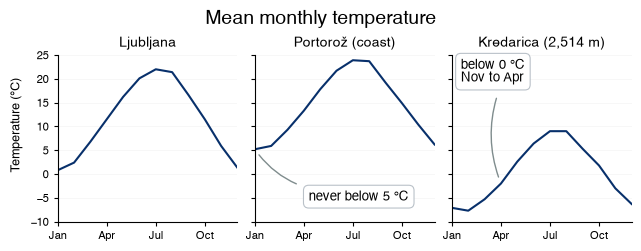

In [10]:
stations = [
    [{"x": i, "y": value} for i, value in enumerate(values)]
    for values in STATION_TEMPERATURES.values()
]

LineChart(
    data=stations,
    subtitle=list(STATION_TEMPERATURES),
    subplots=True,
    sharey=True,
    ymin=-10,
    ymax=25,
    title="Mean monthly temperature",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=[0, 3, 6, 9],
    xticklabels=["Jan", "Apr", "Jul", "Oct"],
    # one list of notes per subplot
    texts=[
        [],
        [{"text": "never below 5 °C", "x": 0.3, "y": 0.15, "coords": "axes", "target": (0, 5.2)}],
        [{"text": "below 0 °C\nNov to Apr", "x": 0.05, "y": 0.9, "coords": "axes", "target": (3, -2.0)}],
    ],
).show()

## Annotating Finished Figures

Notes are often added last: the figure comes from someone else's code, or the message is only clear once the chart is drawn. The [datachart.utils.Annotate](../../../references/utils/#datachart.utils.Annotate) function takes a figure drawn by a chart function and the annotations to add, in the same form as `texts`. It returns a **new** figure and leaves the source figure untouched; the notes become part of the new figure's chart declaration and are styled by the theme active when `Annotate` is called.

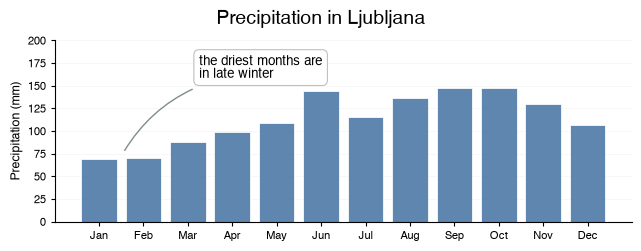

In [11]:
precipitation = BarChart(
    data=precipitation_data,
    title="Precipitation in Ljubljana",
    ylabel="Precipitation (mm)",
    figsize=FIG_SIZE.FULL_SHORT,
    ymax=200,
)

# a new figure; `precipitation` stays as it was
Annotate(
    precipitation,
    texts={
        "text": "the driest months are\nin late winter",
        "x": 0.25,
        "y": 0.85,
        "coords": "axes",
        "target": (0.5, 72),
    },
).show()

### Annotating a panel

A panel is the typical figure that is finished before its message is: the overlay of precipitation and temperature (a *climograph*) shows a pattern that no single chart shows. `Annotate` accepts [Panel](../panel/) figures; the note below is placed on the axes and points at the September precipitation bar.

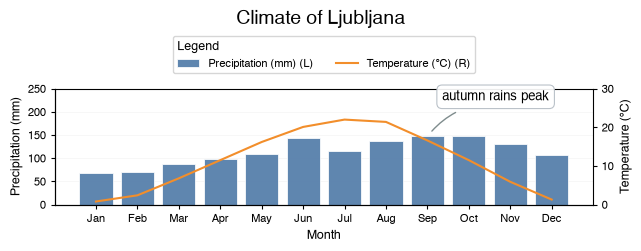

In [12]:
from datachart.constants import LEGEND_LOCATION

climograph = Panel(
    [
        BarChart(data=precipitation_data, subtitle="Precipitation (mm)"),
        LineChart(data=temperature_data, subtitle="Temperature (°C)"),
    ],
    title="Climate of Ljubljana",
    xlabel="Month",
    ylabel_left="Precipitation (mm)",
    ylabel_right="Temperature (°C)",
    # headroom above the bars and the line for the notes
    ymin=0,
    ymax=250,
    ymin_right=0,
    ymax_right=30,
    figsize=FIG_SIZE.FULL_SHORT,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.OUTSIDE_TOP, "ncols": 2},
)

Annotate(
    climograph,
    texts={
        "text": "autumn rains peak",
        "x": 0.72,
        "y": 0.93,
        "coords": "axes",
        "target": (8, 147),
    },
).show()

### Annotating finished subplots

A finished figure drawn with `subplots=True` has one coordinate space per subplot, so each note names the subplot it lands in with a `subplot` index: 0-based, in the order the subplots are drawn. `Annotate` raises a `ValueError` when a note on such a figure has no `subplot` or one out of range, and when a note names a `subplot` on a single-panel figure. The annotated figure keeps the subplot layout, with each subplot scaled on its own, and composes onward with [Grid](../grid/); in a Panel, where the subplots collapse into one coordinate space, the subplot notes are not drawn. Here the mountain station, the third subplot, gets the note:

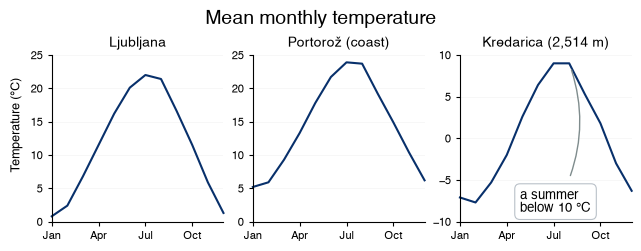

In [13]:
station_figure = LineChart(
    data=stations,
    subtitle=list(STATION_TEMPERATURES),
    subplots=True,
    title="Mean monthly temperature",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=[0, 3, 6, 9],
    xticklabels=["Jan", "Apr", "Jul", "Oct"],
)

Annotate(
    station_figure,
    texts={
        "text": "a summer\nbelow 10 °C",
        "x": 0.35,
        "y": 0.12,
        "coords": "axes",
        "target": (7, 9.0),
        # the third subplot
        "subplot": 2,
    },
).show()

### Annotations in a grid

A [Grid](../grid/) redraws each figure in a cell of its own, and the notes of each figure travel with it. A Grid figure itself cannot be annotated: `Annotate` raises a `ValueError` for it, because a grid has no single coordinate space to place a note in. Annotate the figures first, then compose them, as the [last example](#example-3-how-does-ljubljanas-climate-compare-an-annotated-panel-and-subplots-in-a-grid) of this guide does:

In [14]:
try:
    Annotate(Grid([climograph]), texts={"text": "too late", "x": 0.5, "y": 0.5})
except ValueError as error:
    print(error)

Grid figures cannot be annotated; annotate the source figures before composing them with Grid.


## Text Configuration

The defaults every annotation falls back on (the font, the box face and edge, the connector look and color) are part of the global configuration, under the keys that start with `plot_text_`. Every predefined theme sets them to match its own look, and they are changed like any other setting, through [datachart.config.config.update_config](../../../references/config/#datachart.config.Config.update_config); see the [Themes](../../styling/themes/) guide for the configuration system as a whole. The current keys and their values in the active theme are:

In [15]:
from datachart.config import config

{key: value for key, value in config.config.items() if key.startswith("plot_text_")}

{'plot_text_color': None,
 'plot_text_size': 9.5,
 'plot_text_weight': 'normal',
 'plot_text_halign': 'left',
 'plot_text_valign': 'center',
 'plot_text_alpha': 1.0,
 'plot_text_box_visible': True,
 'plot_text_box_style': 'round,pad=0.4',
 'plot_text_box_facecolor': '#FFFFFF',
 'plot_text_box_edgecolor': '#B4BCC4',
 'plot_text_box_edge_width': 0.8,
 'plot_text_box_alpha': 0.92,
 'plot_text_arrow_style': 'curve',
 'plot_text_arrow_curve': None,
 'plot_text_arrow_color': '#7F8C8D',
 'plot_text_arrow_width': 1.0}

A `plot_text_*` key in an annotation's `style` always wins over the configuration. The configuration is the place for a default that should hold for every annotation of a document, such as arrowheads on every connector and notes without a box:

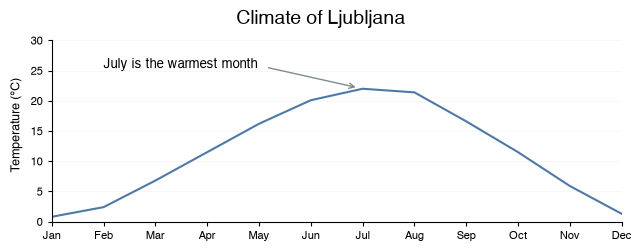

In [16]:
config.update_config(
    {
        # arrowheads and boxless notes for every annotation
        "plot_text_arrow_style": ARROW_STYLE.ARROW,
        "plot_text_box_visible": False,
    }
)

LineChart(
    data=temperature_data,
    title="Climate of Ljubljana",
    ylabel="Temperature (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    xticks=list(range(12)),
    xticklabels=MONTHS,
    ymax=30,
    texts={"text": "July is the warmest month", "x": 1, "y": 26, "target": (6, 22.0)},
).show()

# restore the defaults for the rest of the guide
config.reset_config()

## Real-World Examples

The examples below put annotations to work on real or illustrative data, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: What Made 2024 the Warmest Year? (A Highlighted Record and Quiet Context Notes)

`warming` holds the global mean surface temperature anomaly from 1970 to 2024, the difference of each year's global average from the 1951–1980 mean in °C (source: NASA GISS Surface Temperature Analysis, GISTEMP v4, rounded to two decimals). A line of fifty years says *warming*; the notes say why single years stand out. The record gets the loud treatment, a bold note with an arrowhead. The context gets quiet, boxless notes: the dip after the eruption of Mount Pinatubo in 1991, the spike of the strong 1997–98 El Niño, and the previous record of 2016, marked with a dashed reference line so the reader can see by how much 2024 beat it.

In [17]:
# global mean surface temperature anomaly in °C relative to 1951-1980 (NASA GISTEMP v4, rounded)
YEARS = list(range(1970, 2025))
ANOMALY = [
    0.03, -0.08, 0.01, 0.16, -0.07, -0.01, -0.10, 0.18, 0.07, 0.16,
    0.26, 0.32, 0.14, 0.31, 0.16, 0.12, 0.18, 0.32, 0.39, 0.27,
    0.45, 0.41, 0.22, 0.23, 0.32, 0.45, 0.33, 0.46, 0.61, 0.38,
    0.39, 0.54, 0.63, 0.62, 0.53, 0.68, 0.64, 0.66, 0.54, 0.66,
    0.72, 0.61, 0.65, 0.68, 0.75, 0.90, 1.02, 0.92, 0.85, 0.98,
    1.01, 0.85, 0.89, 1.17, 1.28,
]
assert len(ANOMALY) == len(YEARS)
BY_YEAR = dict(zip(YEARS, ANOMALY))
warming = [{"x": year, "y": anomaly} for year, anomaly in BY_YEAR.items()]

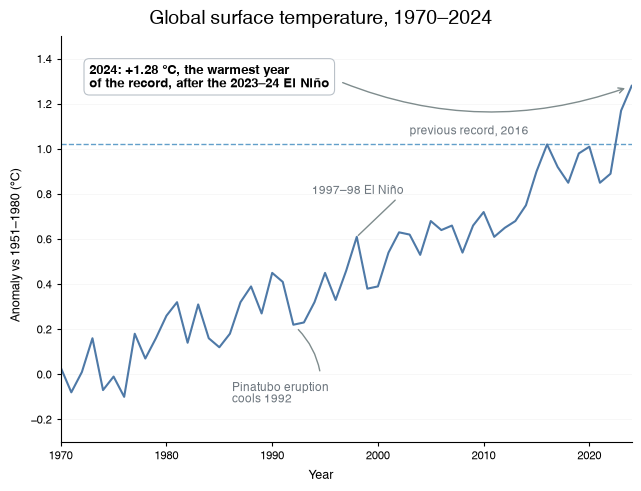

In [18]:
from datachart.constants import LINE_STYLE, SHOW_GRID

quiet = {"plot_text_box_visible": False, "plot_text_color": "#6c757d", "plot_text_size": 8.5}

LineChart(
    data=warming,
    title="Global surface temperature, 1970–2024",
    xlabel="Year",
    ylabel="Anomaly vs 1951–1980 (°C)",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    ymin=-0.3,
    ymax=1.5,
    # the previous record, for comparison
    hlines={"y": BY_YEAR[2016], "style": {"plot_hline_style": LINE_STYLE.DASHED}},
    texts=[
        # the record: bold, boxed, with an arrowhead
        {
            "text": f"2024: {BY_YEAR[2024]:+.2f} °C, the warmest year\nof the record, after the 2023–24 El Niño",
            "x": 0.05,
            "y": 0.9,
            "coords": "axes",
            "target": (2024, BY_YEAR[2024]),
            "style": {"plot_text_weight": "bold", "plot_text_arrow_style": ARROW_STYLE.CURVE_ARROW},
        },
        # the context: quiet, boxless notes
        {
            "text": "previous record, 2016",
            "x": 2003,
            "y": BY_YEAR[2016] + 0.06,
            "style": quiet,
        },
        {
            "text": "Pinatubo eruption\ncools 1992",
            "x": 0.3,
            "y": 0.12,
            "coords": "axes",
            "target": (1992, BY_YEAR[1992]),
            "style": quiet,
        },
        {
            "text": "1997–98 El Niño",
            "x": 0.44,
            "y": 0.62,
            "coords": "axes",
            "target": (1998, BY_YEAR[1998]),
            "style": quiet,
        },
    ],
).show()

### Example 2: What Moved the Traffic? (Event Notes on a Date Axis)

`visits` holds the illustrative daily visits of a product website from March to May 2024, generated with a seeded weekly cycle and noise, and `EVENTS` the three days that moved it: a product launch, an outage, and a mention in a large newsletter. A traffic chart without notes shows jumps; with notes it shows their causes. Each event gets its own note with an arrowhead, placed above or below the line where there is room. The chart's x-axis holds dates, and a note position on a date axis is a number: [matplotlib.dates.date2num](https://matplotlib.org/stable/api/dates_api.html#matplotlib.dates.date2num) converts each date.

In [19]:
from datetime import date, timedelta

import numpy as np

rng = np.random.RandomState(42)
START = date(2024, 3, 1)
DAYS = [START + timedelta(days=i) for i in range(92)]
LAUNCH, OUTAGE, NEWSLETTER = date(2024, 4, 2), date(2024, 4, 23), date(2024, 5, 14)
EVENTS = {"launch": LAUNCH, "outage": OUTAGE, "newsletter": NEWSLETTER}

counts = []
for day in DAYS:
    # a weekday/weekend cycle around a base level that rises after the launch
    level = 1200 if day < LAUNCH else 1900 + 900 * np.exp(-(day - LAUNCH).days / 6)
    level *= 0.75 if day.weekday() >= 5 else 1.0
    if day == OUTAGE:
        level = 320
    if 0 <= (day - NEWSLETTER).days <= 4:
        level += 3400 * np.exp(-(day - NEWSLETTER).days / 1.2)
    counts.append(int(level * (1 + rng.randn() * 0.05)))

VISITS = dict(zip(DAYS, counts))
visits = [{"x": day, "y": count} for day, count in VISITS.items()]

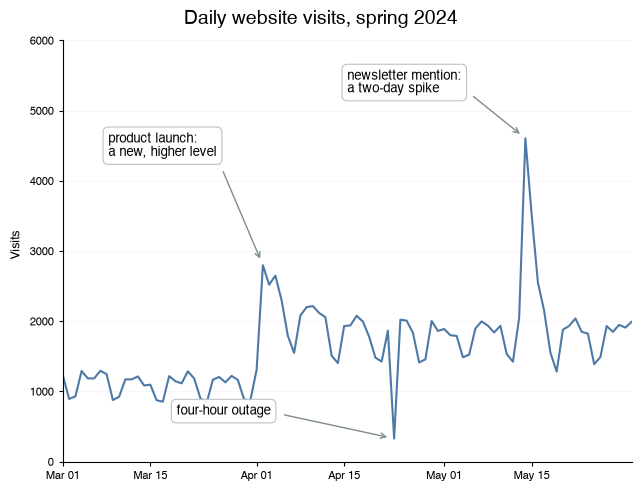

In [20]:
from matplotlib.dates import date2num


def event_note(text, day, x, y):
    # a note at (x, y) axes fractions, pointing at the visits of `day`
    return {
        "text": text,
        "x": x,
        "y": y,
        "coords": "axes",
        "target": (date2num(day), VISITS[day]),
        "style": {"plot_text_arrow_style": ARROW_STYLE.ARROW},
    }


LineChart(
    data=visits,
    title="Daily website visits, spring 2024",
    ylabel="Visits",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_grid=SHOW_GRID.Y,
    xticks_format="%b %d",
    ymin=0,
    ymax=6000,
    texts=[
        event_note("product launch:\na new, higher level", EVENTS["launch"], 0.08, 0.75),
        event_note("four-hour outage", EVENTS["outage"], 0.2, 0.12),
        event_note("newsletter mention:\na two-day spike", EVENTS["newsletter"], 0.5, 0.9),
    ],
).show()

### Example 3: How Does Ljubljana's Climate Compare? (An Annotated Panel and Subplots in a Grid)

The last example uses the Basics dataset to build one figure for a report: the Ljubljana climograph on top, with its notes added by `Annotate`, and the three stations below, with their notes declared per subplot on the chart's own `texts`. Both figures carry their notes into the [Grid](../grid/), which stacks them in two rows; the station subtitles carry the unit, since each station is drawn in a cell of its own. The notes are added before the grid is built, since a Grid figure cannot be annotated.

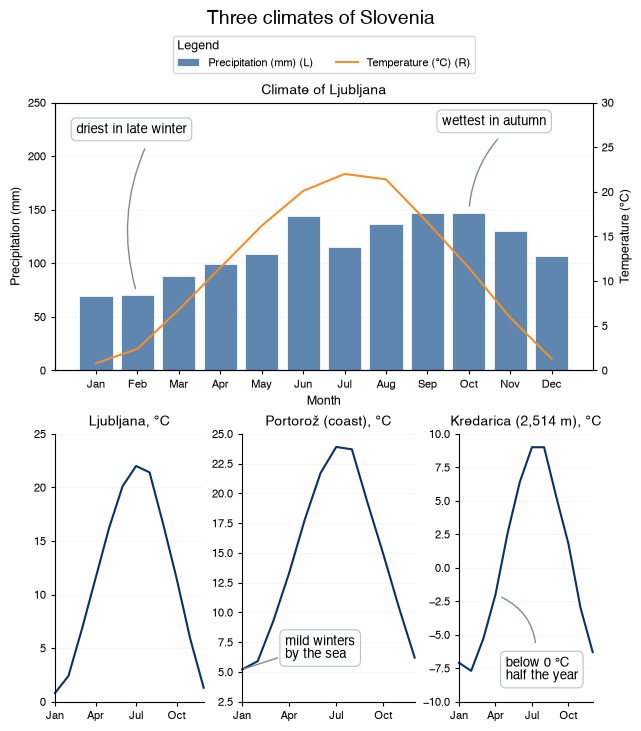

In [21]:
top = Annotate(
    climograph,
    texts=[
        {"text": "driest in late winter", "x": 0.04, "y": 0.9, "coords": "axes", "target": (1, 70)},
        {"text": "wettest in autumn", "x": 0.72, "y": 0.93, "coords": "axes", "target": (9, 147)},
    ],
)

bottom = LineChart(
    data=stations,
    # the unit rides the subtitles
    subtitle=[f"{name}, °C" for name in STATION_TEMPERATURES],
    subplots=True,
    xticks=[0, 3, 6, 9],
    xticklabels=["Jan", "Apr", "Jul", "Oct"],
    # one list of notes per subplot
    texts=[
        [],
        [{"text": "mild winters\nby the sea", "x": 0.25, "y": 0.2, "coords": "axes", "target": (0, 5.2)}],
        [{"text": "below 0 °C\nhalf the year", "x": 0.35, "y": 0.12, "coords": "axes", "target": (3, -2.0)}],
    ],
)

Grid(
    [[top], [bottom]],
    title="Three climates of Slovenia",
    figsize=FIG_SIZE.FULL_TALL,
).show()